## Importing Libraries

In [1]:
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.applications import DenseNet121
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten,BatchNormalization
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

## Data Preprocessing

In [2]:
train_datagen = ImageDataGenerator(
      rescale = 1./255,
      rotation_range=30,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      vertical_flip=True)

test_datagen = ImageDataGenerator(rescale = 1./255)

val_datagen = ImageDataGenerator(rescale = 1./255)

### Training Image Preprocessing

In [3]:
# Define dataset directories
train_ds = train_datagen.flow_from_directory(
    'train',
    class_mode='categorical',
    batch_size=32,
    target_size=(256, 256),
)

test_ds = test_datagen.flow_from_directory(
    'test',
    class_mode='categorical',
    batch_size=32,
    target_size=(256, 256),
    shuffle=False,
)

val_ds = val_datagen.flow_from_directory(
    'validation',
    class_mode='categorical',
    batch_size=32,
    target_size=(256, 256),
    shuffle=False,
)

Found 8686 images belonging to 9 classes.
Found 1869 images belonging to 9 classes.
Found 1859 images belonging to 9 classes.


In [4]:
images_train = 0  # Initialize the image count

# Iterate through subdirectories in 'train'
for dir in os.listdir('train'):
    subdir_path = os.path.join('train', dir)  # Construct the full path

    # Check if it is a directory
    if os.path.isdir(subdir_path):
        # Count files in the subdirectory
        num_files = len([file for file in os.listdir(subdir_path) if os.path.isfile(os.path.join(subdir_path, file))])
        print(f'The number of train images inside the sub-directory "{dir}": {num_files}')
        images_train += num_files  # Add the file count to the total

# Print the total count of images
print()
print(f'Total number of images in "train": {images_train}')


The number of train images inside the sub-directory "Bacterial Leaf Blight": 1108
The number of train images inside the sub-directory "Brown Spot": 1082
The number of train images inside the sub-directory "Healthy Rice Leaf": 857
The number of train images inside the sub-directory "Leaf Blast": 1223
The number of train images inside the sub-directory "Leaf scald": 932
The number of train images inside the sub-directory "Narrow Brown Leaf Spot": 735
The number of train images inside the sub-directory "Neck_Blast": 700
The number of train images inside the sub-directory "Rice Hispa": 909
The number of train images inside the sub-directory "Sheath Blight": 1140

Total number of images in "train": 8686


In [5]:
images_test = 0  # Initialize the image count

# Iterate through subdirectories in 'train'
for dir in os.listdir('test'):
    subdir_path = os.path.join('test', dir)  # Construct the full path

    # Check if it is a directory
    if os.path.isdir(subdir_path):
        # Count files in the subdirectory
        num_files = len([file for file in os.listdir(subdir_path) if os.path.isfile(os.path.join(subdir_path, file))])
        print(f'The number of test images inside the sub-directory "{dir}": {num_files}')
        images_test += num_files  # Add the file count to the total

# Print the total count of images
print()
print(f'Total number of images in "test": {images_test}')


The number of test images inside the sub-directory "Bacterial Leaf Blight": 238
The number of test images inside the sub-directory "Brown Spot": 233
The number of test images inside the sub-directory "Healthy Rice Leaf": 185
The number of test images inside the sub-directory "Leaf Blast": 263
The number of test images inside the sub-directory "Leaf Scald": 201
The number of test images inside the sub-directory "Narrow Brown Leaf Spot": 158
The number of test images inside the sub-directory "Neck Blast": 150
The number of test images inside the sub-directory "Rice Hispa": 196
The number of test images inside the sub-directory "Sheath Blight": 245

Total number of images in "test": 1869


In [6]:
images_validation = 0  # Initialize the image count

# Iterate through subdirectories in 'train'
for dir in os.listdir('validation'):
    subdir_path = os.path.join('validation', dir)  # Construct the full path

    # Check if it is a directory
    if os.path.isdir(subdir_path):
        # Count files in the subdirectory
        num_files = len([file for file in os.listdir(subdir_path) if os.path.isfile(os.path.join(subdir_path, file))])
        print(f'The number of test images inside the sub-directory "{dir}": {num_files}')
        images_validation += num_files  # Add the file count to the total

# Print the total count of images
print()
print(f'Total number of images in "validation": {images_validation}')


The number of test images inside the sub-directory "Bacterial Leaf Blight": 238
The number of test images inside the sub-directory "Brown Spot": 231
The number of test images inside the sub-directory "Healthy Rice Leaf": 183
The number of test images inside the sub-directory "Leaf Blast": 262
The number of test images inside the sub-directory "Leaf Scald": 199
The number of test images inside the sub-directory "Narrow Brown Leaf Spot": 158
The number of test images inside the sub-directory "Neck Blast": 150
The number of test images inside the sub-directory "Rice Hispa": 194
The number of test images inside the sub-directory "Sheath Blight": 244

Total number of images in "validation": 1859


### Building Model

In [7]:
conv_l = DenseNet121(weights = 'imagenet',
             include_top = False,
             input_shape = (256,256,3))

In [8]:
conv_l.trainable = False

In [9]:
model = Sequential()

### Building Convolution Layer

In [10]:
model.add(conv_l)
model.add(BatchNormalization())
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(BatchNormalization())
model.add(Dense(9,activation='softmax'))

### Building Convolution Layer

In [11]:
from tensorflow.keras.utils import Sequence

class CustomDataset(Sequence):
    def __init__(self, data, labels, batch_size, **kwargs):
        super().__init__(**kwargs)  # Ensure this is called
        self.data = data
        self.labels = labels
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(len(self.data) / self.batch_size))

    def __getitem__(self, index):
        batch_data = self.data[index * self.batch_size:(index + 1) * self.batch_size]
        batch_labels = self.labels[index * self.batch_size:(index + 1) * self.batch_size]
        return batch_data, batch_labels


### Compiling and Training Phase

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)             │ (None, 8, 8, 1024)          │       7,037,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 8, 8, 1024)          │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 65536)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      16,777,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 9)                   │           2,313 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,822,409 (90.88 MB)

 Trainable params: 16,782,345 (64.02 MB)

 Non-trainable params: 7,040,064 (26.86 MB)

In [13]:
# Define batch size and initial learning rate
batch_size = 32
initial_lr = 0.001

# Compile the model with the Adam optimizer and loss function
opt = Adam(learning_rate=initial_lr)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

# Train the model
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[early_stopping],
)

C:\Users\Clarise Mae B. Elle\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 691s 2s/step - accuracy: 0.6091 - loss: 1.4654 - val_accuracy: 0.8209 - val_loss: 0.4963
Epoch 2/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 639s 2s/step - accuracy: 0.7974 - loss: 0.5784 - val_accuracy: 0.8494 - val_loss: 0.4022
Epoch 3/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 636s 2s/step - accuracy: 0.8240 - loss: 0.4935 - val_accuracy: 0.8913 - val_loss: 0.3108
Epoch 4/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 637s 2s/step - accuracy: 0.8442 - loss: 0.4272 - val_accuracy: 0.9053 - val_loss: 0.2521
Epoch 5/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 656s 2s/step - accuracy: 0.8672 - loss: 0.3813 - val_accuracy: 0.9209 - val_loss: 0.2415
Epoch 6/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 641s 2s/step - accuracy: 0.8743 - loss: 0.3532 - val_accuracy: 0.9306 - val_loss: 0.2030
Epoch 7/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 649s 2s/step - accuracy: 0.8860 - loss: 0.3228 - val_accuracy: 0.9344 - val_loss: 0.1921
Epoch 8/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 638s 2s/step - accuracy: 0.8908 - loss: 0.3085 - val_accu

### Evaluating Model

In [14]:
train_loss, train_acc = model.evaluate(train_ds)
print(f'Training accuracy: {train_acc:.2f}')

272/272 ━━━━━━━━━━━━━━━━━━━━ 503s 2s/step - accuracy: 0.9613 - loss: 0.1122
Training accuracy: 0.96


In [15]:
#Validation set Accuracy
val_loss, val_acc = model.evaluate(val_ds)
print(f'Validation accuracy: {val_acc:.2f}')

59/59 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9860 - loss: 0.0413    
Validation accuracy: 0.98


In [16]:
#Testing set Accuracy
test_loss, test_acc = model.evaluate(test_ds)
print(f'Test accuracy: {test_acc:.2f}')

59/59 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.9879 - loss: 0.0423    
Test accuracy: 0.99


### Model Evaluation with Threshold

In [29]:
# Define the confidence threshold
threshold = 0.6  # Set the threshold you want to use
print(f"Using threshold: {threshold}")  # Debugging: Ensure the correct threshold is being applied


# Test set evaluation with threshold
test_probs = model.predict(test_ds)  # Predict probabilities for test set
print("Test predictions completed.")  # Debugging: Confirm predictions are done

# Apply threshold to test predictions
filtered_test_true_labels = []
filtered_test_pred_labels = []

for i, prob in enumerate(test_probs):
    max_prob = np.max(prob)  # Get the highest probability
    if max_prob >= threshold:
        filtered_test_true_labels.append(test_ds.labels[i])  # Keep corresponding true label
        filtered_test_pred_labels.append(np.argmax(prob))  # Keep predicted class
    # If below threshold, do nothing (discard low-confidence predictions)

# Calculate test accuracy for high-confidence predictions
if len(filtered_test_true_labels) > 0:  # Ensure there are valid predictions
    test_accuracy = np.sum(np.array(filtered_test_true_labels) == np.array(filtered_test_pred_labels)) / len(filtered_test_true_labels)
    print(f"Test Accuracy with Threshold {threshold}: {test_accuracy:.2f}")

    # Percentage of low-confidence predictions filtered out
    test_filtered_out_percentage = (len(test_ds.labels) - len(filtered_test_true_labels)) / len(test_ds.labels) * 100
    print(f"Percentage of low-confidence test predictions filtered out: {test_filtered_out_percentage:.2f}%")
else:
    print("No predictions met the confidence threshold in the test set.")

Using threshold: 0.6
59/59 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step
Test predictions completed.
Test Accuracy with Threshold 0.6: 0.99
Percentage of low-confidence test predictions filtered out: 1.23%


In [30]:
# Validation set evaluation with threshold
val_probs = model.predict(val_ds)  # Predict probabilities for validation set
print("Validation predictions completed.")  # Debugging: Confirm predictions are done

# Apply threshold to validation predictions
filtered_val_true_labels = []
filtered_val_pred_labels = []

for i, prob in enumerate(val_probs):
    max_prob = np.max(prob)  # Get the highest probability
    if max_prob >= threshold:
        filtered_val_true_labels.append(val_ds.labels[i])  # Keep corresponding true label
        filtered_val_pred_labels.append(np.argmax(prob))  # Keep predicted class
    # If below threshold, do nothing (discard low-confidence predictions)

# Calculate validation accuracy for high-confidence predictions
if len(filtered_val_true_labels) > 0:  # Ensure there are valid predictions
    val_accuracy = np.sum(np.array(filtered_val_true_labels) == np.array(filtered_val_pred_labels)) / len(filtered_val_true_labels)
    print(f"Validation Accuracy with Threshold {threshold}: {val_accuracy:.2f}")

    # Percentage of low-confidence predictions filtered out
    val_filtered_out_percentage = (len(val_ds.labels) - len(filtered_val_true_labels)) / len(val_ds.labels) * 100
    print(f"Percentage of low-confidence validation predictions filtered out: {val_filtered_out_percentage:.2f}%")
else:
    print("No predictions met the confidence threshold in the validation set.")

59/59 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step
Validation predictions completed.
Validation Accuracy with Threshold 0.6: 0.99
Percentage of low-confidence validation predictions filtered out: 1.61%


### Saving Model

In [37]:
model.save('trained_rice_disease_model_with_threshold.keras')

In [20]:
history.history

{'accuracy': [0.6942206025123596,
  0.7970296740531921,
  0.829035222530365,
  0.8482615947723389,
  0.866106390953064,
  0.8753166198730469,
  0.8845268487930298,
  0.8897075653076172,
  0.89396733045578,
  0.9030624032020569,
  0.9116969704627991,
  0.9120423793792725,
  0.9187197685241699,
  0.9161869883537292,
  0.9267787337303162,
  0.9250518083572388,
  0.9282754063606262,
  0.9334561228752136,
  0.9298871755599976,
  0.9350679516792297,
  0.9350679516792297,
  0.9441630244255066,
  0.9400184154510498,
  0.9401335716247559,
  0.94450843334198,
  0.9422058463096619,
  0.947271466255188,
  0.9484227299690247],
 'loss': [0.9884089827537537,
  0.5732012391090393,
  0.48633599281311035,
  0.42697200179100037,
  0.3858676254749298,
  0.3545595705509186,
  0.32787808775901794,
  0.3074202537536621,
  0.2988477945327759,
  0.27336135506629944,
  0.25171583890914917,
  0.2502007782459259,
  0.2289312481880188,
  0.23466438055038452,
  0.21016912162303925,
  0.2179686427116394,
  0.2064289

In [21]:
#Recording History in json
import json
with open('rice_training_hist.json','w') as f:
  json.dump(history.history,f)

In [22]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## Accuracy Visualization

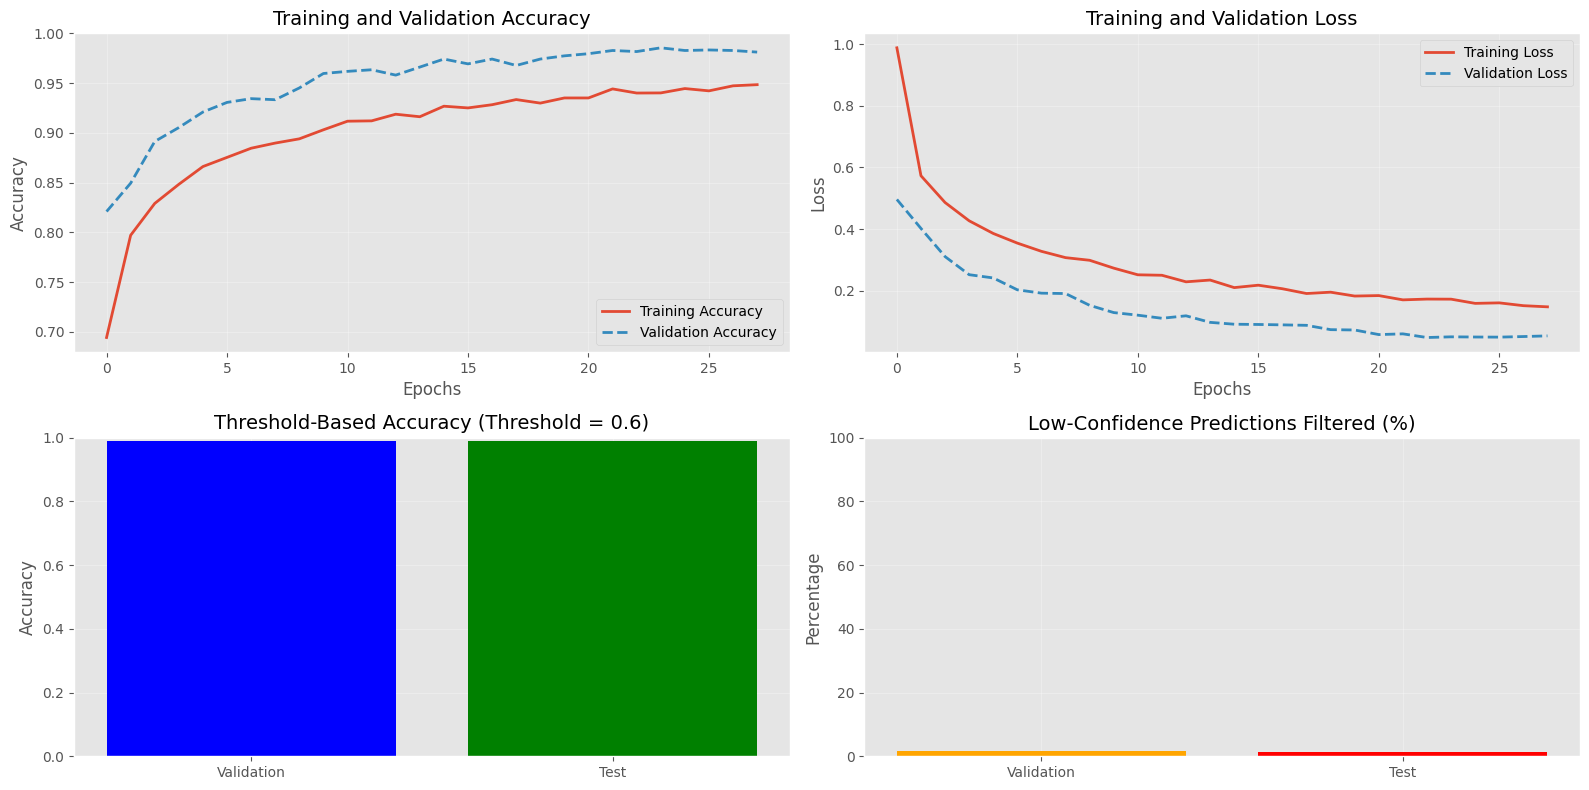

In [31]:
def plot_training_and_threshold_results(history, val_threshold_accuracy, val_filtered_out_percentage, 
                                        test_threshold_accuracy, test_filtered_out_percentage, threshold):
    # Extract data from history
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    # Define a consistent style
    plt.style.use('ggplot')

    # Create the figure
    plt.figure(figsize=(16, 8))

    # Plot training and validation accuracy
    plt.subplot(2, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--', linewidth=2)
    plt.legend(loc='lower right', fontsize=10)
    plt.title('Training and Validation Accuracy', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.grid(alpha=0.3)

    # Plot training and validation loss
    plt.subplot(2, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--', linewidth=2)
    plt.legend(loc='upper right', fontsize=10)
    plt.title('Training and Validation Loss', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(alpha=0.3)

    # Plot threshold-based accuracy
    plt.subplot(2, 2, 3)
    plt.bar(['Validation', 'Test'], [val_threshold_accuracy, test_threshold_accuracy], color=['blue', 'green'])
    plt.title(f'Threshold-Based Accuracy (Threshold = {threshold})', fontsize=14)
    plt.ylabel('Accuracy', fontsize=12)
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)

    # Plot low-confidence filtered percentage
    plt.subplot(2, 2, 4)
    plt.bar(['Validation', 'Test'], [val_filtered_out_percentage, test_filtered_out_percentage], color=['orange', 'red'])
    plt.title('Low-Confidence Predictions Filtered (%)', fontsize=14)
    plt.ylabel('Percentage', fontsize=12)
    plt.ylim(0, 100)
    plt.grid(alpha=0.3)

    # Tight layout for better spacing
    plt.tight_layout()

    # Show the plots
    plt.show()

# Call the function with your calculated threshold metrics
plot_training_and_threshold_results(
    history=history,
    val_threshold_accuracy=0.99,  # Replace with your actual calculated value
    val_filtered_out_percentage=1.61,  # Replace with your actual calculated value
    test_threshold_accuracy=0.99,  # Replace with your actual calculated value
    test_filtered_out_percentage=1.23,  # Replace with your actual calculated value
    threshold=0.6  # Replace with the threshold used
)

## Some other metrics for model evaluation

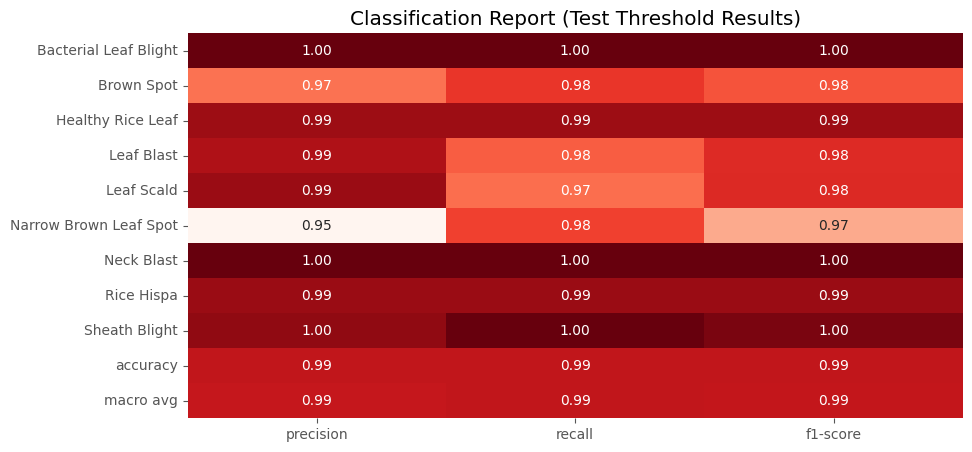

In [32]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generate a classification report for test threshold results
report = classification_report(
    filtered_test_true_labels,  # True labels from test set after threshold filtering
    filtered_test_pred_labels,  # Predicted labels from test set after threshold filtering
    target_names=list(test_ds.class_indices.keys()),  # Class names from the dataset
    output_dict=True  # Generate output as a dictionary
)

# Convert the report to a DataFrame for better visualization
report_df = pd.DataFrame(report).transpose()

# Plot the classification report as a heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap=plt.cm.Reds, fmt=".2f", cbar=False)
plt.title('Classification Report (Test Threshold Results)')
plt.show()

### Confusion Matrix Visualization

59/59 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step


<Figure size 1400x1200 with 0 Axes>

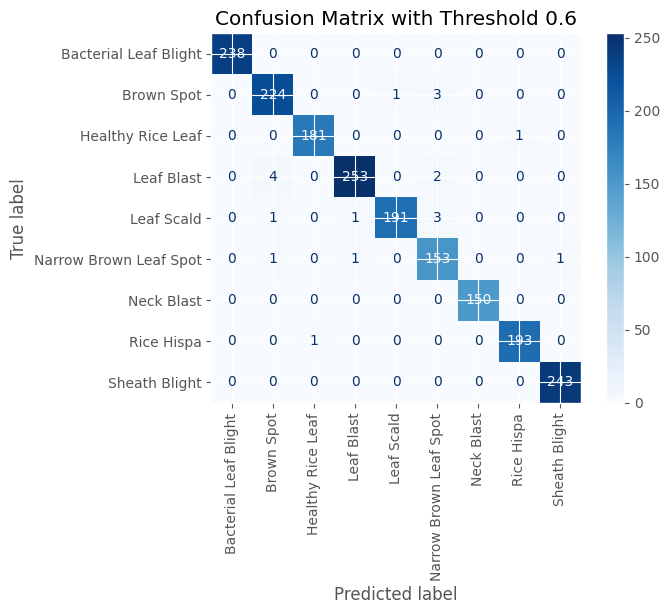

Percentage of low-confidence predictions filtered out: 1.23%


In [38]:
# Define a threshold
threshold = 0.6 # Set the desired confidence threshold

# Get true labels from the 'test_ds' directory iterator
true_labels = test_ds.labels

# Predict probabilities for the test dataset
pred_probs = model.predict(test_ds)

# Apply threshold to predictions
filtered_predictions = []
for prob in pred_probs:
    max_prob = np.max(prob)
    if max_prob >= threshold:
        filtered_predictions.append(np.argmax(prob))  # Assign the class with max prob
    else:
        filtered_predictions.append(-1)  # Assign -1 for uncertain predictions

# Filter out uncertain predictions from the confusion matrix calculation
filtered_true_labels = []
filtered_pred_labels = []
for true_label, pred_label in zip(true_labels, filtered_predictions):
    if pred_label != -1:  # Exclude uncertain predictions
        filtered_true_labels.append(true_label)
        filtered_pred_labels.append(pred_label)

# Calculate confusion matrix only for confident predictions
conf_matrix = confusion_matrix(filtered_true_labels, filtered_pred_labels)

# Get class labels from the generator
class_labels = list(test_ds.class_indices.keys())

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_labels)

# Plot the confusion matrix
plt.figure(figsize=(14, 12))
disp.plot(cmap=plt.cm.Blues)

# Rotate x-axis labels by 90 degrees
plt.xticks(rotation=90)

plt.title(f'Confusion Matrix with Threshold {threshold}')
plt.show()

# Print the percentage of predictions filtered out due to low confidence
filtered_out_percentage = (len(true_labels) - len(filtered_true_labels)) / len(true_labels) * 100
print(f"Percentage of low-confidence predictions filtered out: {filtered_out_percentage:.2f}%")